# Análisis Exploratorio de Datos — ASL Alphabet

**Laboratorio 3, Deep Learning — CC3084**

SignBridge necesita reconocer letra por letra las señas del alfabeto ASL. Preguntas a responder:

1. Resolución y formato de las imágenes.
2. ¿Está balanceado el dataset?
3. Variabilidad dentro de una misma clase.
4. Letras que se confunden visualmente.
5. Cómo se construyó el split train/val/test.

Trabajo sobre `01_particiones.csv`, `data/raw/` y `02_tensores.npz`, generados por el pipeline en `src/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

sys.path.insert(0, str(Path.cwd().parent / "src"))
import config as cfg

plt.rcParams["figure.facecolor"] = "white"
RNG = np.random.default_rng(cfg.SEMILLA)

df = pd.read_csv(cfg.RUTA_PARTICIONES)
df.head()

,ruta,clase,particion
0,data/raw/asl_alphabet_train/A/A685.jpg,A,train
1,data/raw/asl_alphabet_train/A/A2559.jpg,A,train
2,data/raw/asl_alphabet_train/A/A2804.jpg,A,train
3,data/raw/asl_alphabet_train/A/A1676.jpg,A,train
4,data/raw/asl_alphabet_train/A/A1439.jpg,A,train


Cada fila es una imagen: ruta relativa, clase y partición (`train`/`val`/`test`).

## 1. Resolución y formato

Se abren imágenes crudas al azar para confirmar tamaño, modo de color y formato.

In [2]:
muestra_formato = df.sample(30, random_state=cfg.SEMILLA)

registros = []
for ruta in muestra_formato["ruta"]:
    with Image.open(cfg.RAIZ / ruta) as img:
        registros.append({"tamano": img.size, "modo": img.mode, "formato": img.format})

resumen = pd.DataFrame(registros)
print("Tamaños distintos encontrados:", resumen["tamano"].unique())
print("Modos de color distintos:", resumen["modo"].unique())
print("Formatos distintos:", resumen["formato"].unique())

Tamaños distintos encontrados: [(200, 200)]
Modos de color distintos: ['RGB']
Formatos distintos: ['JPEG']


**Hallazgo:** todas las imágenes son 200x200 px, RGB, JPEG — sin excepciones. El dataset ya viene uniforme, no hace falta normalizar tamaños antes de reescalar a 64x64.

## 2. ¿Está balanceado el dataset?

Conteo de imágenes por clase: dataset crudo y submuestra.

In [3]:
conteo_crudo = {
    clase: len(list((cfg.RUTA_TRAIN_CRUDO / clase).glob("*.jpg")))
    for clase in cfg.CLASES
}
conteo_crudo = pd.Series(conteo_crudo, name="imagenes").sort_index()
print("Crudo -> min:", conteo_crudo.min(), "max:", conteo_crudo.max(), "clases distintas de conteo:", conteo_crudo.nunique())

Crudo -> min: 3000 max: 3000 clases distintas de conteo: 1


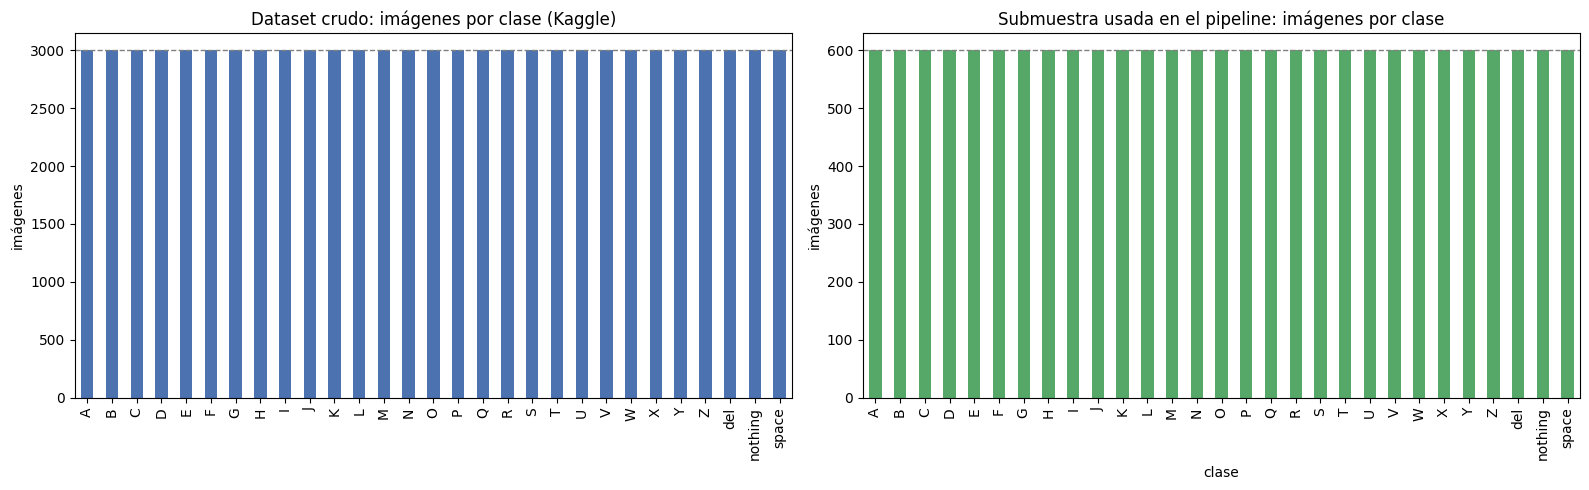

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

conteo_crudo.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Dataset crudo: imágenes por clase (Kaggle)")
axes[0].set_ylabel("imágenes")
axes[0].axhline(cfg.IMGS_POR_CLASE_CRUDO, color="gray", linestyle="--", linewidth=1)

conteo_submuestra = df["clase"].value_counts().sort_index()
conteo_submuestra.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Submuestra usada en el pipeline: imágenes por clase")
axes[1].set_ylabel("imágenes")
axes[1].axhline(cfg.IMGS_POR_CLASE, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

**Hallazgo:** perfectamente balanceado. 3,000 img/clase en crudo (87,000 total), 600/clase en la submuestra (por construcción del pipeline). No hace falta class weights ni accuracy balanceado.

## 3. Ejemplos y variabilidad intra-clase

6 muestras de 5 letras (formas de mano distintas: puño, palma abierta, dedos extendidos).

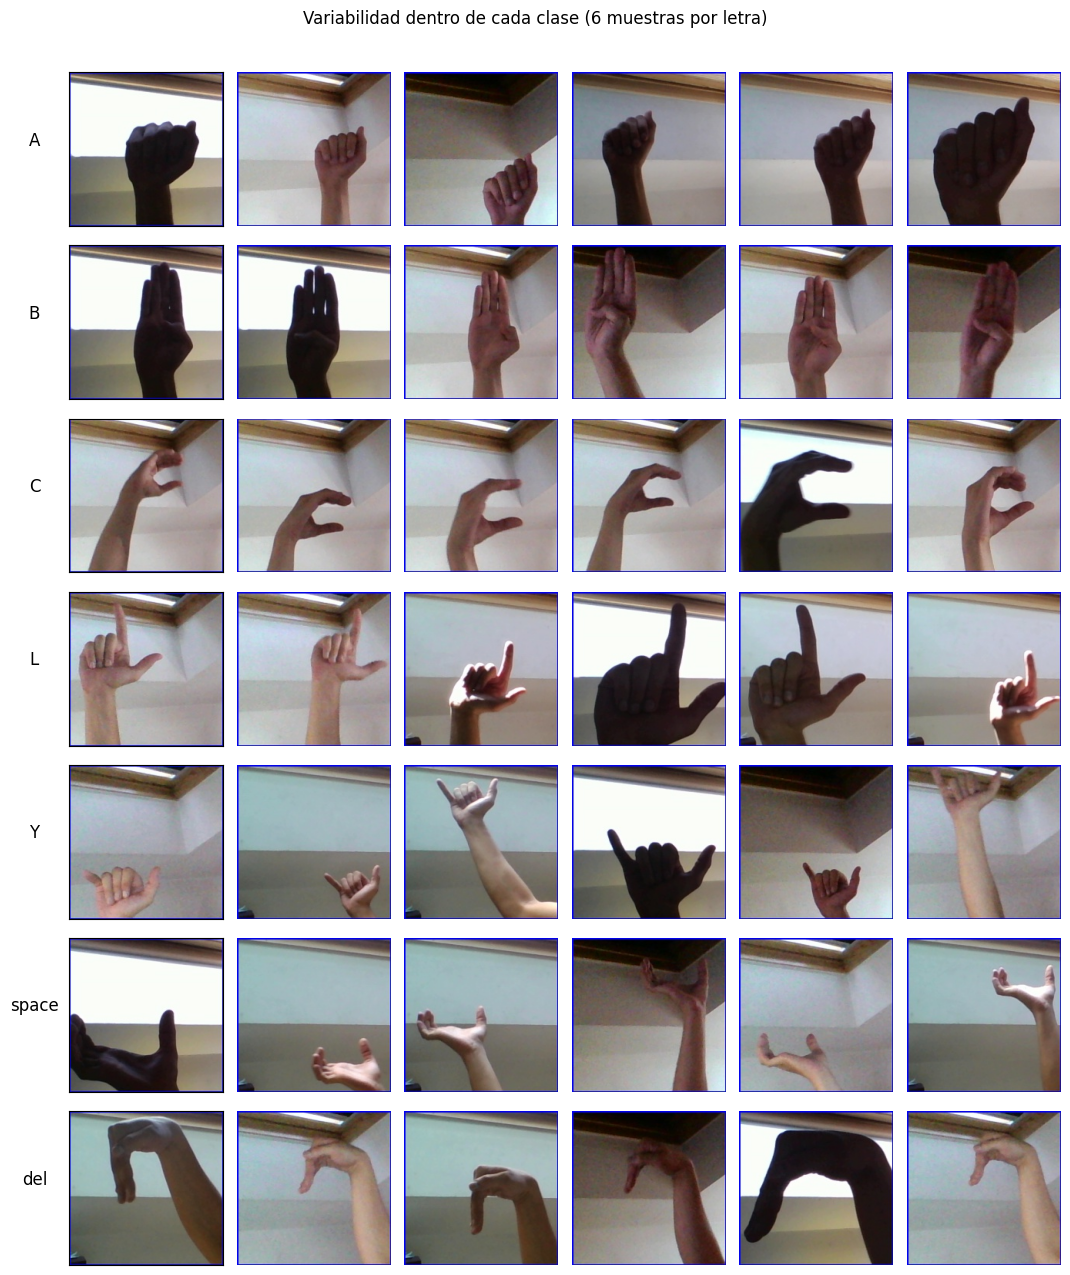

In [5]:
# 5 letras del alfabeto (lo que pide el ejercicio 1) mas las 2 clases de accion
letras_ejemplo = ["A", "B", "C", "L", "Y", "space", "del"]
n_muestras = 6

fig, axes = plt.subplots(len(letras_ejemplo), n_muestras, figsize=(n_muestras * 1.8, len(letras_ejemplo) * 1.8))

for fila, letra in enumerate(letras_ejemplo):
    rutas = df.loc[df["clase"] == letra, "ruta"].sample(n_muestras, random_state=cfg.SEMILLA).tolist()
    for col, ruta in enumerate(rutas):
        ax = axes[fila, col]
        with Image.open(cfg.RAIZ / ruta) as img:
            ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(letra, rotation=0, labelpad=25, fontsize=12)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle("Variabilidad dentro de cada clase (6 muestras por letra)", y=1.01)
plt.tight_layout()
plt.show()

**Hallazgo:** dentro de cada clase el fondo y la iluminación son consistentes, señal de pocas sesiones de grabación en vez de miles de personas distintas. Relevante para el punto 9 (accesibilidad/sesgo): poca variedad de fondos, iluminación y tono de piel generaliza peor a uso real.

## 4. Letras visualmente confundibles

Se agrupan letras por forma de mano (ver `cfg.GRUPOS_CONFUNDIBLES`): las que comparten forma son las más propensas a confundir a un clasificador basado en píxeles.

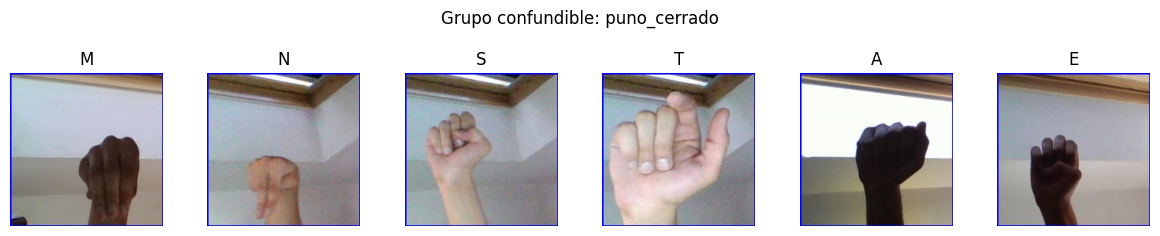

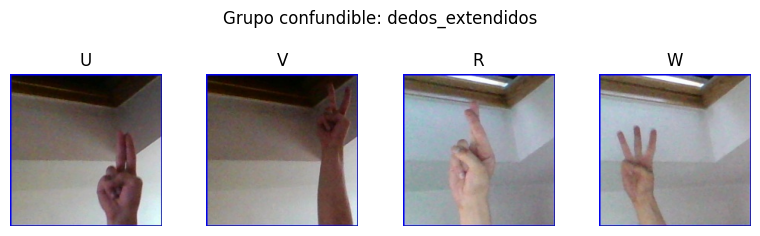

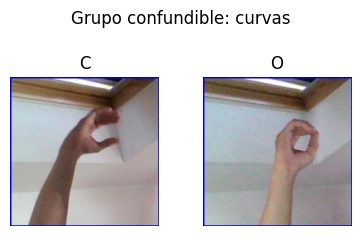

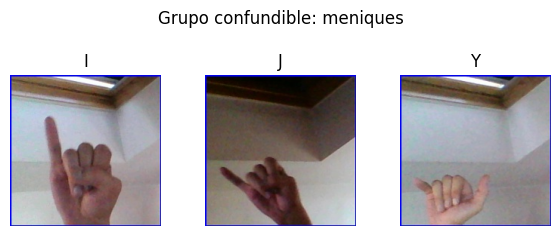

In [6]:
for grupo, letras in cfg.GRUPOS_CONFUNDIBLES.items():
    fig, axes = plt.subplots(1, len(letras), figsize=(len(letras) * 2, 2.2))
    for ax, letra in zip(axes, letras):
        ruta = df.loc[df["clase"] == letra, "ruta"].sample(1, random_state=cfg.SEMILLA).iloc[0]
        with Image.open(cfg.RAIZ / ruta) as img:
            ax.imshow(img)
        ax.set_title(letra)
        ax.axis("off")
    plt.suptitle(f"Grupo confundible: {grupo}", y=1.05)
    plt.tight_layout()
    plt.show()

**Hallazgo por grupo:**

- **`puno_cerrado` (M, N, S, T, A, E):** puño cerrado; difieren en dónde queda el pulgar. Mayor riesgo de confusión, y aumenta a 64x64 porque el pulgar es el detalle que se pierde al reescalar.
- **`dedos_extendidos` (U, V, R, W):** difieren en cuántos dedos se levantan y si están cruzados (R) o separados (V).
- **`curvas` (C, O):** difieren en qué tan cerrado queda el círculo.
- **`meniques` (I, J, Y):** en video J se distingue por trayectoria; como imagen estática puede confundirse con I.

Si el error de los modelos se concentra en estos grupos, es un límite del dataset (poses estáticas 2D), no un defecto del modelo.

## 5. Split train/val/test

El test set oficial de Kaggle solo trae 28 fotos, insuficiente para evaluar. `01_particiones.py` construye el propio:

1. Submuestra `IMGS_POR_CLASE = 600` por clase, con semilla fija (`SEMILLA = 123`) → reproducible.
2. Reparto estratificado por clase: 70% train / 15% val / 15% test.
3. El set de Kaggle (28 img) queda aparte en `data/raw/asl_alphabet_test/` como evaluación final opcional.

In [7]:
tabla_split = df.groupby(["clase", "particion"]).size().unstack()
print("Filas de la tabla clase x partición con conteo distinto entre clases:", (tabla_split.nunique(axis=0) != 1).sum())
tabla_split.head()

Filas de la tabla clase x partición con conteo distinto entre clases: 0


particion,test,train,val
clase,,,
A,90,420,90
B,90,420,90
C,90,420,90
D,90,420,90
E,90,420,90


In [8]:
resumen_split = df["particion"].value_counts().rename("imagenes").to_frame()
resumen_split["proporcion"] = (resumen_split["imagenes"] / len(df)).round(3)
resumen_split

,imagenes,proporcion
particion,,
train,12180,0.70
val,2610,0.15
test,2610,0.15


**Verificación:** 420/90/90 imágenes por clase en train/val/test, sin diferencias entre clases (estratificado correctamente).

## 6. Brillo por clase (post-preprocesamiento)

Brillo promedio del train ya en grises/64x64, para detectar clases con iluminación distinta.

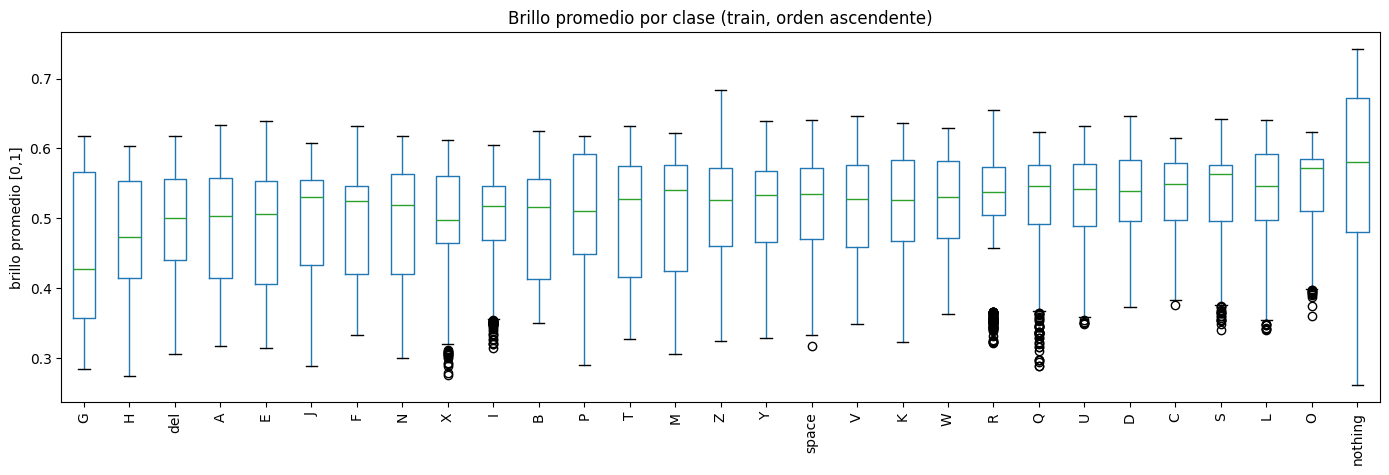

In [9]:
tensores = np.load(cfg.RUTA_TENSORES)
x_train, y_train, clases = tensores["x_train"], tensores["y_train"], tensores["clases"]

brillo_promedio = x_train.mean(axis=(1, 2, 3))
df_brillo = pd.DataFrame({"clase": clases[y_train], "brillo": brillo_promedio})

orden = df_brillo.groupby("clase")["brillo"].mean().sort_values().index
df_brillo["clase"] = pd.Categorical(df_brillo["clase"], categories=orden, ordered=True)

fig, ax = plt.subplots(figsize=(14, 5))
df_brillo.boxplot(column="brillo", by="clase", ax=ax, rot=90, grid=False)
ax.set_title("Brillo promedio por clase (train, orden ascendente)")
plt.suptitle("")
ax.set_xlabel("")
ax.set_ylabel("brillo promedio [0,1]")
plt.tight_layout()
plt.show()

**Hallazgo:** el brillo varía entre clases (rango ~0.10 en promedio); `nothing`, `G` y `H` se separan un poco del resto, el resto está agrupado. No es una separación fuerte, pero vale la pena vigilarlo al revisar errores del modelo.

## Conclusiones

- Formato uniforme (200x200 RGB JPEG) y dataset perfectamente balanceado: no hace falta normalizar tamaños ni compensar clases.
- Poca variabilidad intra-clase (fondos/sesiones repetidas) → limitación de generalización, ver punto 9.
- Grupos confundibles por forma de mano: `M/N/S/T/A/E`, `U/V/R/W`, `C/O`, `I/J/Y`, con riesgo mayor a 64x64.
- Split 70/15/15 propio, estratificado y reproducible por semilla, reemplaza al test set de Kaggle.